# Cetacean Detection — Model vs Expert Comparison (ARBAS) 

Compares model predictions (5-second segments) against expert annotations (1-minute WAV files).

- `expert_annotated` now derived from a merge **indicator**, not from a value column that is later `fillna`-ed — so a WAV the expert listened to but found *empty* is correctly `both_negative`, not `no_expert_label`.
- Thousands-separator regex no longer mangles legit values like `2.500` → `2500`; it only fires on true multi-group numbers.
- `exp_top_species` ties reported; `idxmax` first-wins behaviour made explicit.
- Model-side duplicate `(wav_name, segment_index)` guard added.
- Spectrogram glob anchored so a stem can't match a longer stem as a substring.
- Summary plot (c) set-difference precedence bug fixed.

### Resolution mismatch
Expert labels are at 1-minute resolution → broadcast to all 12 × 5 s segments of that WAV.

### Three prediction strategies (same MLP, different post-hoc decoding)
| Strategy | How it decides | Failure mode |
|---|---|---|
| `argmax` | plain softmax argmax | over-predicts background |
| `vec` | per-class `w·logit + b`, inv-freq weighted | hallucinates on ambiguous segments |
| `pr` | argmax among species clearing F1-optimal threshold, else background | lowest hallucination |

### Consensus (`pred_consensus`)
All three agree → that label; else `'uncertain'`.

### Species mapping
- `Delphinidae_unknown` ↔ `Ambig`; `background` ↔ all expert votes 0
- Common: Dd Gg Gm Oo Pm Sc Tt Ambig
- Only model: Ba Bp · Only expert: Dc Lo Zc Bb

In [11]:
# ── 0. Imports & paths ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── EDIT THESE ───────────────────────────────────────────────────────────────
MY_PREDICTIONS_CSV = r"/data2/mromaniuc/cet-det/inference/inference_arbas/predictions/arbas_predictions_l4.csv"
EXPERT_MAY_XLSX    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/comparison/expert_validated_data/XIULOS_MAIG_TOTAL.xlsx"
EXPERT_AUG_XLSX    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/comparison/expert_validated_data/XiulosAGOST_TOTAL.xlsx"
SPECTROGRAM_DIR    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/spectrograms/spectrograms"
OUTPUT_CSV         = "arbas_comparison_5s_v3.csv"

EXPERT_MAY_SHEET   = 'in'
EXPERT_AUG_SHEET   = 'XiulosAGOST_TOTAL'
# ─────────────────────────────────────────────────────────────────────────────

# ── Separator-agnostic basename ──────────────────────────────────────────────
# A Windows path string ('D:\\dir\\file.wav') on a Linux pathlib does NOT split
# on backslash — Path('D:\\...').name returns the whole string. This is the
# classic cause of zero-match merges. Normalise both separators ourselves.
def normalise_wav_name(x):
    """Return just 'XXXX.wav' from any path, Windows or POSIX, with cleanup."""
    if pd.isna(x):
        return None
    s = str(x).strip().strip('"').strip("'")
    s = s.replace('\\\\', '/').replace('\\', '/')   # collapse Windows separators
    s = s.split('/')[-1]                             # take basename
    s = s.strip().lower()                            # case-insensitive match
    if not s.endswith('.wav'):
        s = s + '.wav'
    return s

print("Config loaded. Quick self-test of normalise_wav_name:")
for t in [r'D:\\IM-23-ARBAS\\Soundtrap 6338\\6338.240528160459.wav',
          '6338.240528160459.wav', ' 6312.240806141558 ']:
    print(f"  {t!r:70s} -> {normalise_wav_name(t)!r}")

Config loaded. Quick self-test of normalise_wav_name:
  'D:\\\\IM-23-ARBAS\\\\Soundtrap 6338\\\\6338.240528160459.wav'         -> '6338.240528160459.wav'
  '6338.240528160459.wav'                                                -> '6338.240528160459.wav'
  ' 6312.240806141558 '                                                  -> '6312.240806141558.wav'


In [12]:
# ── 1. Load model predictions ────────────────────────────────────────────────
df_mine = pd.read_csv(MY_PREDICTIONS_CSV)
print(f"Raw CSV: {len(df_mine):,} rows, {df_mine.shape[1]} columns")

# Identify the wav-path column robustly
PATH_COL = next((c for c in ['wav_path', 'wav_name', 'file', 'filename', 'path']
                 if c in df_mine.columns), None)
assert PATH_COL is not None, f"No path column found. Columns: {list(df_mine.columns)}"
print(f"Using '{PATH_COL}' as the wav path column.")

df_mine['wav_name'] = df_mine[PATH_COL].apply(normalise_wav_name)
print(f"Example normalised wav_name: {df_mine['wav_name'].iloc[0]!r}")

# Rename raw prob columns to short codes
# top_predicted_class / top_logit_score are Perch's raw output — IGNORED throughout
PROB_RENAME = {
    'prob_Balaenoptera_acutorostrata': 'prob_Ba',
    'prob_Balaenoptera_physalus':      'prob_Bp',
    'prob_Delphinidae_unknown':        'prob_Ambig',
    'prob_Delphinus_delphis':          'prob_Dd',
    'prob_Globicephala_melas':         'prob_Gm',
    'prob_Grampus_griseus':            'prob_Gg',
    'prob_Orcinus_orca':               'prob_Oo',
    'prob_Physeter_macrocephalus':     'prob_Pm',
    'prob_Stenella_coeruleoalba':      'prob_Sc',
    'prob_Tursiops_truncatus':         'prob_Tt',
    'prob_background':                 'prob_bg',
}
df_mine.rename(columns=PROB_RENAME, inplace=True)

CETACEAN_PROB_COLS = ['prob_Ba','prob_Bp','prob_Ambig','prob_Dd','prob_Gm',
                      'prob_Gg','prob_Oo','prob_Pm','prob_Sc','prob_Tt']
missing_probs = [c for c in CETACEAN_PROB_COLS + ['prob_bg'] if c not in df_mine.columns]
assert not missing_probs, f"Missing probability columns after rename: {missing_probs}"

# Strategy columns (already in CSV)
STRAT_COLS = ['pred_argmax', 'pred_vec', 'pred_pr']
for col in STRAT_COLS:
    assert col in df_mine.columns, f"Strategy column '{col}' not in CSV. " \
        f"Columns: {[c for c in df_mine.columns if c.startswith('pred')]}"

# v4: guard against duplicate (wav_name, segment_index) on the MODEL side.
# The expert dup-guard in cell 2 only protects the right-hand frame; a dup here
# would double-count segments in every breakdown and the viewer.
if 'segment_index' in df_mine.columns:
    seg_dups = df_mine.duplicated(subset=['wav_name', 'segment_index']).sum()
    if seg_dups:
        print(f"  ⚠ {seg_dups} duplicate (wav_name, segment_index) row(s) in model CSV "
              f"— keeping first.")
        df_mine = df_mine.drop_duplicates(subset=['wav_name', 'segment_index'],
                                          keep='first').reset_index(drop=True)

# Normalise strategy label strings (strip whitespace, unify background spelling)
for col in STRAT_COLS:
    df_mine[col] = df_mine[col].astype(str).str.strip()

# Consensus: all three agree → that label; else 'uncertain'
def make_consensus(row):
    labels = {row['pred_argmax'], row['pred_vec'], row['pred_pr']}
    return row['pred_argmax'] if len(labels) == 1 else 'uncertain'
df_mine['pred_consensus'] = df_mine.apply(make_consensus, axis=1)

# Detection flags per strategy
for s in ['argmax', 'vec', 'pr', 'consensus']:
    df_mine[f'cetacean_{s}'] = df_mine[f'pred_{s}'] != 'background'
# uncertain is neither background nor a clean detection → not a confirmed detection
df_mine.loc[df_mine['pred_consensus'] == 'uncertain', 'cetacean_consensus'] = False

# Max cetacean prob — DISPLAY/FILTER only, never used for classification
df_mine['max_cetacean_prob'] = df_mine[CETACEAN_PROB_COLS].max(axis=1)

print(f"\nLoaded {len(df_mine):,} segments from {df_mine['wav_name'].nunique():,} WAV files")
for s in ['argmax', 'vec', 'pr', 'consensus']:
    n = df_mine[f'cetacean_{s}'].sum()
    print(f"  {s:10s}: {n:,} cetacean ({100*n/len(df_mine):.1f}%)")
print(f"  {'uncertain':10s}: {(df_mine['pred_consensus']=='uncertain').sum():,}")

df_mine[['wav_name','segment_index','offset_s',
         'pred_argmax','pred_vec','pred_pr','pred_consensus']].head(8)

Raw CSV: 117,650 rows, 23 columns
Using 'wav_path' as the wav path column.
Example normalised wav_name: '6338.240528160459.wav'

Loaded 117,650 segments from 9,805 WAV files
  argmax    : 37,916 cetacean (32.2%)
  vec       : 57,351 cetacean (48.7%)
  pr        : 18,349 cetacean (15.6%)
  consensus : 18,348 cetacean (15.6%)
  uncertain : 39,189


,wav_name,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus
0,6338.240528160459.wav,0,0.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
1,6338.240528160459.wav,1,5.0,Delphinidae_unknown,Delphinidae_unknown,background,uncertain
2,6338.240528160459.wav,2,10.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
3,6338.240528160459.wav,3,15.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
4,6338.240528160459.wav,4,20.0,background,Delphinidae_unknown,background,uncertain
5,6338.240528160459.wav,5,25.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
6,6338.240528160459.wav,6,30.0,background,Delphinidae_unknown,background,uncertain
7,6338.240528160459.wav,7,35.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown


In [13]:
# ── 2. Load expert annotations ───────────────────────────────────────────────
# May    : sheet 'in'                (single sheet)
# August : sheet 'XiulosAGOST_TOTAL' (ignore 'Hoja1')

EXPERT_VOTE_RENAME = {
    'Ambig_votes': 'exp_Ambig',
    'Bb_votes':    'exp_Bb',   # Berardius bairdii — not in model vocab
    'Dc_votes':    'exp_Dc',   # Delphinus capensis — not in model vocab
    'Dd_votes':    'exp_Dd',
    'Gg_votes':    'exp_Gg',
    'Gm_votes':    'exp_Gm',
    'Lo_votes':    'exp_Lo',   # Lagenorhynchus obliquidens — not in model vocab
    'Oo_votes':    'exp_Oo',
    'Pm_votes':    'exp_Pm',
    'Sc_votes':    'exp_Sc',
    'Tt_votes':    'exp_Tt',
    'Zc_votes':    'exp_Zc',   # Ziphius cavirostris — not in model vocab
}
EXP_VOTE_COLS = list(EXPERT_VOTE_RENAME.values())

# PAMGuard vote counts live in [0, ~10). Many cells were corrupted by a
# number-format / locale artefact that INFLATED the value by a power of 10:
# the true 6.6773 was stored as the float 6.677e16 and displayed via a '#,##0'
# format as '66.773.333.333.333.300'. The corruption is purely multiplicative
# by 10**k, so it shifts the exponent but preserves the significant digits.
# Recovery = read the mantissa: divide the magnitude by 10 until it is < VOTE_MAX.
#
# v4's mistake: it CLAMPED every >100 cell to 0, deleting real detections
# wholesale (931 Gg, 695 Tt cells in August alone). v5 recovers them instead.
VOTE_MAX = 10.0   # guard output upper bound; values >= this are treated as inflated

def recover_vote(x):
    """Undo power-of-10 inflation on a single vote cell. Clean values pass through."""
    if pd.isna(x):
        return 0.0
    # Accept either a float (pandas already parsed the inflated value) or a string.
    try:
        f = float(str(x).strip().strip('"').strip("'").replace(',', '.'))
    except (ValueError, TypeError):
        return 0.0
    if f == 0.0:
        return 0.0
    sign = -1.0 if f < 0 else 1.0
    f = abs(f)
    while f >= VOTE_MAX:      # bring mantissa back into [0, VOTE_MAX)
        f /= 10.0
    return sign * f

def clean_vote_series(s):
    """Vectorised recover_vote with a count of how many cells were corrected."""
    raw = pd.to_numeric(s.astype(str).str.strip().str.replace(',', '.', regex=False),
                        errors='coerce')
    n_inflated = int((raw.abs() >= VOTE_MAX).sum())
    out = s.apply(recover_vote)
    return out, n_inflated

def load_expert_sheet(path, sheet_name):
    df = pd.read_excel(path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]   # strip header whitespace

    fname_col = next((c for c in df.columns
                      if c.strip().upper() in ('ARXIU', 'FILENAME', 'WAV', 'FILE')), None)
    if fname_col is None:
        raise ValueError(f"No filename column in {Path(path).name}/{sheet_name}. "
                         f"Columns: {list(df.columns)}")
    df.rename(columns={fname_col: 'wav_name_raw'}, inplace=True)
    df['wav_name'] = df['wav_name_raw'].apply(normalise_wav_name)

    df.rename(columns=EXPERT_VOTE_RENAME, inplace=True)
    audit = {}
    for col in EXP_VOTE_COLS:
        if col in df.columns:
            df[col], n_inflated = clean_vote_series(df[col])
            if n_inflated:
                audit[col] = n_inflated
        else:
            df[col] = 0.0   # species column absent in this sheet

    if audit:
        total = sum(audit.values())
        print(f"  {Path(path).name}: recovered {total} inflated vote cell(s) "
              f"(power-of-10 artefact): " +
              ", ".join(f"{k.replace('exp_','')}={v}" for k, v in sorted(audit.items())))

    df['source'] = Path(path).stem
    df = df[df['wav_name'].notna()].copy()
    df['exp_cetacean_detected'] = df[EXP_VOTE_COLS].sum(axis=1) > 0

    # idxmax returns the FIRST column on ties — report how often that happens.
    vote_mat = df[EXP_VOTE_COLS]
    row_max = vote_mat.max(axis=1)
    n_ties = ((vote_mat.eq(row_max, axis=0).sum(axis=1) > 1)
              & df['exp_cetacean_detected']).sum()
    if n_ties:
        print(f"  ⚠ {Path(path).name}/{sheet_name}: {n_ties} detected row(s) have a "
              f"top-species tie; idxmax breaks ties by column order.")

    df['exp_top_species'] = vote_mat.idxmax(axis=1).str.replace('exp_', '')
    df.loc[~df['exp_cetacean_detected'], 'exp_top_species'] = 'background'

    # Post-recovery sanity: nothing should exceed the guard ceiling now.
    still_big = (df[EXP_VOTE_COLS] >= VOTE_MAX).any(axis=1).sum()
    if still_big:
        print(f"  ⚠ {Path(path).name}: {still_big} row(s) still >= {VOTE_MAX} after "
              f"recovery — inspect manually.")
    return df

df_exp_may = load_expert_sheet(EXPERT_MAY_XLSX, EXPERT_MAY_SHEET)
df_exp_aug = load_expert_sheet(EXPERT_AUG_XLSX, EXPERT_AUG_SHEET)

print(f"\nMay   : {len(df_exp_may):,} rows  ({df_exp_may['exp_cetacean_detected'].sum()} cetacean)")
print(f"August: {len(df_exp_aug):,} rows  ({df_exp_aug['exp_cetacean_detected'].sum()} cetacean)")

# Guard against duplicate WAV names within the expert data (would inflate the merge)
df_expert = pd.concat([df_exp_may, df_exp_aug], ignore_index=True)
dups = df_expert['wav_name'].duplicated().sum()
if dups:
    print(f"  ⚠ {dups} duplicate wav_name(s) across expert sheets — keeping first.")
    df_expert = df_expert.drop_duplicates(subset='wav_name', keep='first')
print(f"Total : {len(df_expert):,} unique annotated WAVs")

df_expert[['wav_name','source','exp_cetacean_detected','exp_top_species'] + EXP_VOTE_COLS].head()

  XIULOS_MAIG_TOTAL.xlsx: recovered 191 inflated vote cell(s) (power-of-10 artefact): Dc=35, Dd=26, Gg=75, Lo=7, Oo=1, Sc=13, Tt=34
  XiulosAGOST_TOTAL.xlsx: recovered 2545 inflated vote cell(s) (power-of-10 artefact): Dc=412, Dd=196, Gg=933, Lo=46, Oo=8, Sc=255, Tt=695
  ⚠ XiulosAGOST_TOTAL.xlsx/XiulosAGOST_TOTAL: 2 detected row(s) have a top-species tie; idxmax breaks ties by column order.

May   : 4,062 rows  (115 cetacean)
August: 4,005 rows  (1704 cetacean)
Total : 8,067 unique annotated WAVs


,wav_name,source,exp_cetacean_detected,exp_top_species,exp_Ambig,exp_Bb,exp_Dc,exp_Dd,exp_Gg,exp_Gm,exp_Lo,exp_Oo,exp_Pm,exp_Sc,exp_Tt,exp_Zc
0,6338.240528160459.wav,XIULOS_MAIG_TOTAL,False,background,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
1,6338.240528160559.wav,XIULOS_MAIG_TOTAL,False,background,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
2,6338.240528160659.wav,XIULOS_MAIG_TOTAL,False,background,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,6338.240528160759.wav,XIULOS_MAIG_TOTAL,True,Gg,0.0,0.0,0.509333,0.333333,1.380000,0.0,0.242667,0.197333,0.0,0.116000,0.221333,0.0
4,6338.240528160859.wav,XIULOS_MAIG_TOTAL,True,Gg,0.0,0.0,0.869333,0.414667,2.166667,0.0,0.005333,0.000000,0.0,0.090667,0.453333,0.0


In [14]:
# ── 2b. KEY-OVERLAP DIAGNOSTIC (catches merge mismatches before they bite) ──
mine_keys = set(df_mine['wav_name'].dropna().unique())
exp_keys  = set(df_expert['wav_name'].dropna().unique())

overlap = mine_keys & exp_keys
print(f"Model WAVs           : {len(mine_keys):,}")
print(f"Expert WAVs          : {len(exp_keys):,}")
print(f"Overlapping WAVs      : {len(overlap):,}")
print(f"In expert, not model : {len(exp_keys - mine_keys):,}")
print(f"In model, not expert : {len(mine_keys - exp_keys):,}")

if len(overlap) == 0:
    print("\n❌ ZERO OVERLAP — the merge will be empty. Inspect sample keys:")
    print("  model :", sorted(mine_keys)[:3])
    print("  expert:", sorted(exp_keys)[:3])
    print("  → check separators, casing, trailing chars, or .wav suffix.")
else:
    print(f"\n✓ Overlap looks good. Sample matched keys: {sorted(overlap)[:3]}")

Model WAVs           : 9,805
Expert WAVs          : 8,067
Overlapping WAVs      : 8,067
In expert, not model : 0
In model, not expert : 1,738

✓ Overlap looks good. Sample matched keys: ['6312.240806141558.wav', '6312.240806141658.wav', '6312.240806141758.wav']


In [15]:
# ── 3. Merge: broadcast expert 1-min label → all 5 s segments of that WAV ───
EXPERT_KEEP = (['wav_name', 'exp_cetacean_detected', 'exp_top_species',
                'Encounter_Classification', 'source'] + EXP_VOTE_COLS)
EXPERT_KEEP = [c for c in EXPERT_KEEP if c in df_expert.columns]

# v4: derive `expert_annotated` from the merge INDICATOR, not from a value column.
# Previously expert_annotated = exp_cetacean_detected.notna(), but that column is
# fillna(False)-ed right after, and — more importantly — a WAV the expert listened
# to but found EMPTY has exp_cetacean_detected == False, which is semantically a
# `both_negative`, NOT a `no_expert_label`. Using _merge keeps the two distinct.
df = df_mine.merge(df_expert[EXPERT_KEEP], on='wav_name', how='left', indicator=True)
df['expert_annotated'] = df['_merge'] == 'both'
df.drop(columns='_merge', inplace=True)

# Fill expert columns for non-annotated rows so downstream code is safe
for col in EXP_VOTE_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0.0)
# For annotated rows exp_cetacean_detected is already True/False; for
# non-annotated rows it is NaN -> fill False (no detection claimed).
df['exp_cetacean_detected'] = df['exp_cetacean_detected'].fillna(False).astype(bool)
df['exp_top_species'] = df['exp_top_species'].fillna('no_label')

print(f"Total segments           : {len(df):,}")
print(f"  With expert annotation : {df['expert_annotated'].sum():,}")
print(f"  Without                : {(~df['expert_annotated']).sum():,}")
print(f"  Unique annotated WAVs  : {df[df['expert_annotated']]['wav_name'].nunique():,}")

# Sanity: annotated rows where expert found nothing are legit both_negative material.
n_ann_empty = ((df['expert_annotated']) & (~df['exp_cetacean_detected'])).sum()
print(f"  Annotated but empty    : {n_ann_empty:,}  (these are valid both_negative, not no_label)")

assert df['expert_annotated'].sum() > 0, \
    "Still zero annotated segments — re-run the 2b diagnostic and fix key matching."

Total segments           : 117,650
  With expert annotation : 96,794
  Without                : 20,856
  Unique annotated WAVs  : 8,067
  Annotated but empty    : 74,966  (these are valid both_negative, not no_label)


In [16]:
# ── 4. Agreement categories (per strategy) ───────────────────────────────────
SHARED_SPECIES = ['Dd', 'Gg', 'Gm', 'Oo', 'Pm', 'Sc', 'Tt', 'Ambig']

def compute_agreement(df, strategy_col, cetacean_col):
    def agr(row):
        if not row['expert_annotated']:
            return 'no_expert_label'
        me, exp = row[cetacean_col], row['exp_cetacean_detected']
        if me and exp:        return 'both_positive'
        if not me and not exp: return 'both_negative'
        if me and not exp:    return 'only_mine'
        return 'only_expert'

    agree_col = f'agreement_{strategy_col}'
    df[agree_col] = df.apply(agr, axis=1)

    def sp_agr(row):
        if row[agree_col] != 'both_positive':
            return np.nan
        my_sp, exp_sp = row[strategy_col], row['exp_top_species']
        if my_sp not in SHARED_SPECIES or exp_sp not in SHARED_SPECIES:
            return 'partial'
        return 'agree' if my_sp == exp_sp else 'disagree'
    df[f'sp_agreement_{strategy_col}'] = df.apply(sp_agr, axis=1)
    return df

for strat, flag in [('pred_argmax','cetacean_argmax'), ('pred_vec','cetacean_vec'),
                    ('pred_pr','cetacean_pr'), ('pred_consensus','cetacean_consensus')]:
    df = compute_agreement(df, strat, flag)

ann = df[df['expert_annotated']]
print("Agreement breakdown per strategy (annotated segments only):")
for s in ['pred_argmax','pred_vec','pred_pr','pred_consensus']:
    print(f"\n  {s}:")
    print(ann[f'agreement_{s}'].value_counts().to_string())

Agreement breakdown per strategy (annotated segments only):

  pred_argmax:
agreement_pred_argmax
both_negative    43420
only_mine        31546
only_expert      16447
both_positive     5381

  pred_vec:
agreement_pred_vec
only_mine        45170
both_negative    29796
only_expert      11498
both_positive    10330

  pred_pr:
agreement_pred_pr
both_negative    57733
only_expert      20788
only_mine        17233
both_positive     1040

  pred_consensus:
agreement_pred_consensus
both_negative    57733
only_expert      20789
only_mine        17233
both_positive     1039


In [17]:
# ── 5. Consensus / disagreement patterns ─────────────────────────────────────
uncertain = df[df['pred_consensus'] == 'uncertain'].copy()
print(f"Uncertain segments (strategies disagree): {len(uncertain):,} "
      f"({100*len(uncertain)/len(df):.1f}% of all)")

if len(uncertain):
    uncertain['pattern'] = (uncertain['pred_argmax'] + ' / ' +
                            uncertain['pred_vec']    + ' / ' +
                            uncertain['pred_pr'])
    print("\nTop 20 disagreement patterns (argmax / vec / pr):")
    print(uncertain['pattern'].value_counts().head(20).to_string())

    unc_exp_pos = uncertain[uncertain['exp_cetacean_detected'] == True]
    if len(unc_exp_pos):
        print(f"\nUncertain & expert says cetacean: {len(unc_exp_pos):,}")
        print(unc_exp_pos['pattern'].value_counts().head(10).to_string())

Uncertain segments (strategies disagree): 39,189 (33.3% of all)

Top 20 disagreement patterns (argmax / vec / pr):
pattern
Delphinidae_unknown / Delphinidae_unknown / background                  9694
background / Delphinidae_unknown / background                           9261
background / Physeter_macrocephalus / background                        6327
Tursiops_truncatus / Delphinidae_unknown / background                   1898
Tursiops_truncatus / Tursiops_truncatus / background                    1526
background / Stenella_coeruleoalba / background                         1518
Balaenoptera_acutorostrata / Balaenoptera_acutorostrata / background    1497
background / Balaenoptera_acutorostrata / background                    1046
Balaenoptera_physalus / Balaenoptera_physalus / background               818
background / Orcinus_orca / background                                   772
Tursiops_truncatus / Physeter_macrocephalus / background                 767
Physeter_macrocephalus / Physe

In [19]:
# ── 6. Species comparison table (both_positive, shared species) ──────────────
STRATEGY = 'pred_pr'   # 'pred_argmax' | 'pred_vec' | 'pred_pr' | 'pred_consensus'

both_pos = df[df[f'agreement_{STRATEGY}'] == 'both_positive'].copy()
print(f"Both-positive segments under '{STRATEGY}': {len(both_pos):,}\n")

rows = []
for sp in SHARED_SPECIES:
    my_col, exp_col = f'prob_{sp}', f'exp_{sp}'
    if my_col not in both_pos.columns or exp_col not in both_pos.columns:
        continue
    rows.append({
        'species':        sp,
        'my_mean_prob':   round(both_pos[my_col].mean(), 4) if len(both_pos) else np.nan,
        'exp_mean_votes': round(both_pos[exp_col].mean(), 4) if len(both_pos) else np.nan,
        'my_n_top':       int((both_pos[STRATEGY] == sp).sum()),
        'exp_n_top':      int((both_pos['exp_top_species'] == sp).sum()),
        'n_segments':     len(both_pos),
    })
species_df = pd.DataFrame(rows).sort_values('exp_mean_votes', ascending=False)
print(species_df.to_string(index=False))

Both-positive segments under 'pred_pr': 1,040

species  my_mean_prob  exp_mean_votes  my_n_top  exp_n_top  n_segments
     Gg        0.0004          1.7425         0        730        1040
     Tt        0.0708          1.1527         0        253        1040
     Sc        0.0007          0.6060         0         14        1040
     Dd        0.0081          0.5058         0          5        1040
     Oo        0.0196          0.0119         0          0        1040
     Gm        0.0001          0.0000         0          0        1040
     Pm        0.0036          0.0000         0          0        1040
  Ambig        0.8416          0.0000         0          0        1040


In [20]:
# ── 7. Tursiops (Tt) deep-dive — all strategies ──────────────────────────────
from sklearn.metrics import classification_report

ann = df[df['expert_annotated']].copy()
ann['exp_tt_present'] = ann['exp_Tt'] > 0
print(f"Expert says Tt present in {ann['exp_tt_present'].sum():,} annotated segments\n")

for s in ['argmax', 'vec', 'pr', 'consensus']:
    col = f'pred_{s}'
    print(f"── Strategy: {s} ──")
    print(classification_report(
        ann['exp_tt_present'].astype(int),
        (ann[col] == 'Tt').astype(int),
        target_names=['no_Tt', 'Tt'], zero_division=0))

Expert says Tt present in 21,828 annotated segments

── Strategy: argmax ──
              precision    recall  f1-score   support

       no_Tt       0.77      1.00      0.87     74966
          Tt       0.00      0.00      0.00     21828

    accuracy                           0.77     96794
   macro avg       0.39      0.50      0.44     96794
weighted avg       0.60      0.77      0.68     96794

── Strategy: vec ──
              precision    recall  f1-score   support

       no_Tt       0.77      1.00      0.87     74966
          Tt       0.00      0.00      0.00     21828

    accuracy                           0.77     96794
   macro avg       0.39      0.50      0.44     96794
weighted avg       0.60      0.77      0.68     96794

── Strategy: pr ──
              precision    recall  f1-score   support

       no_Tt       0.77      1.00      0.87     74966
          Tt       0.00      0.00      0.00     21828

    accuracy                           0.77     96794
   macro avg 

In [21]:
# ── 8. Save comparison CSV ───────────────────────────────────────────────────
save_cols = ([
    'wav_name', 'segment_index', 'offset_s',
    'pred_argmax', 'pred_vec', 'pred_pr', 'pred_consensus',
    'cetacean_argmax', 'cetacean_vec', 'cetacean_pr', 'cetacean_consensus',
    'max_cetacean_prob',
    'exp_cetacean_detected', 'exp_top_species', 'expert_annotated',
    'agreement_pred_pr', 'sp_agreement_pred_pr',
    'agreement_pred_consensus', 'sp_agreement_pred_consensus',
] + CETACEAN_PROB_COLS + ['prob_bg'] + EXP_VOTE_COLS)
save_cols = [c for c in save_cols if c in df.columns]

df[save_cols].to_csv(OUTPUT_CSV, index=False, float_format='%.6f')
print(f"Saved: {OUTPUT_CSV}  ({len(df):,} rows, {len(save_cols)} cols)")

Saved: arbas_comparison_5s_v3.csv  (117,650 rows, 42 cols)


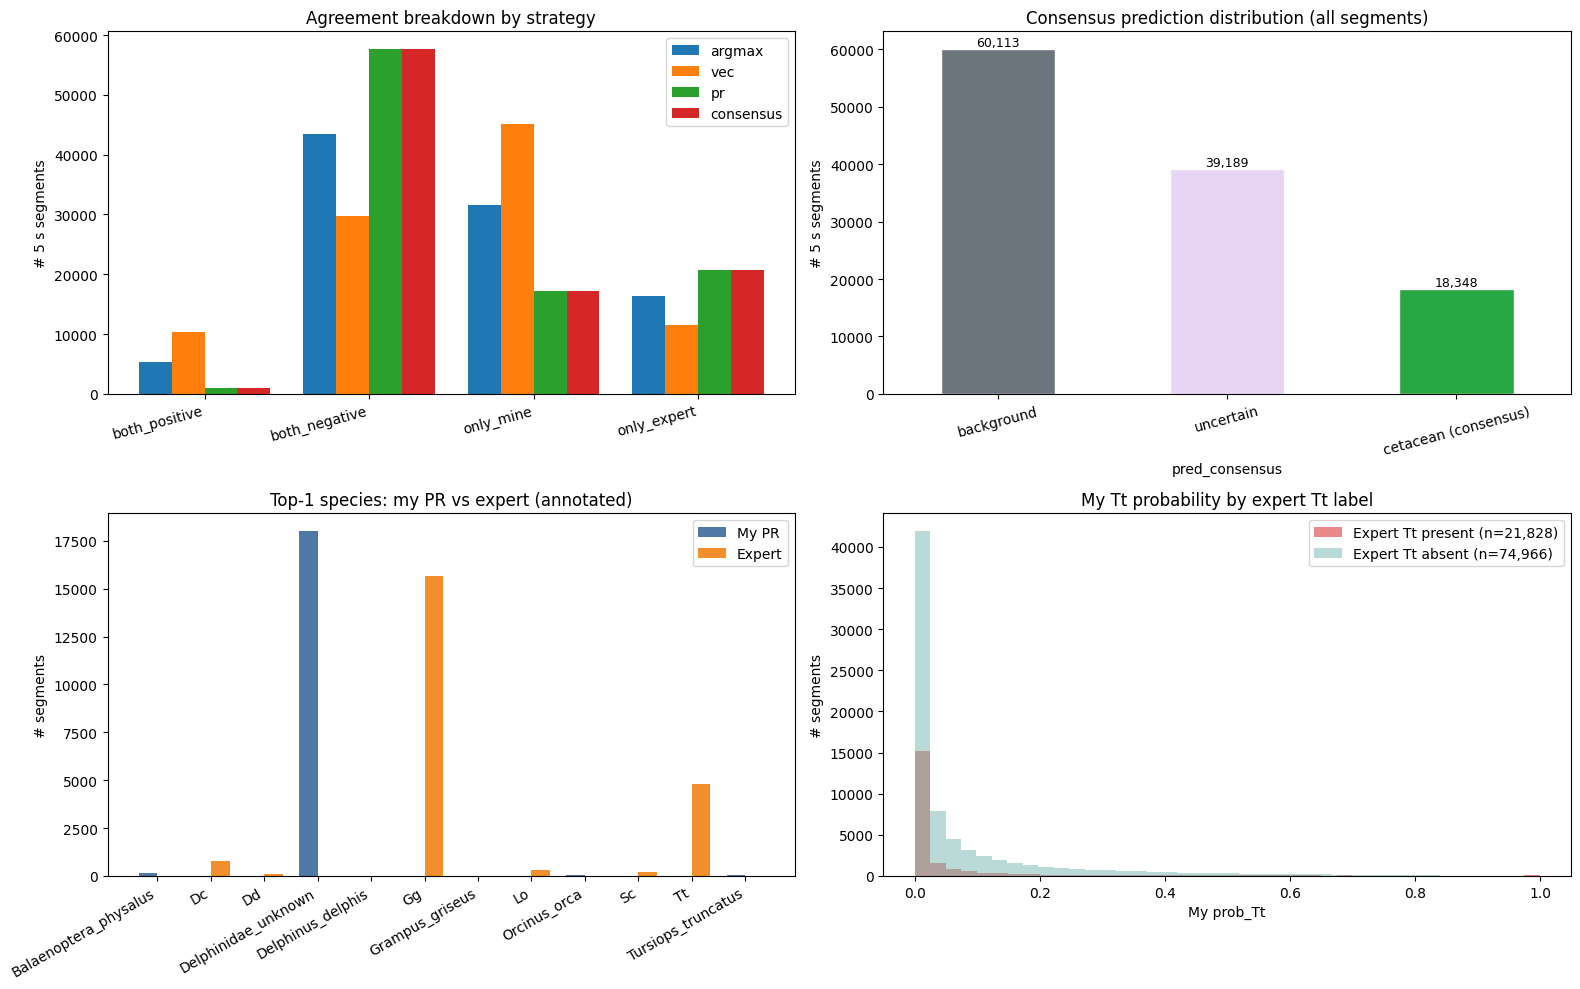

Saved: arbas_comparison_summary_v3.png


In [23]:
# ── 10. Summary plots ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

ann = df[df['expert_annotated']].copy()
if len(ann) == 0:
    print('No annotated segments — skipping plots.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # (a) agreement breakdown per strategy
    ax = axes[0,0]
    cats = ['both_positive','both_negative','only_mine','only_expert']
    strategies = ['pred_argmax','pred_vec','pred_pr','pred_consensus']
    x = np.arange(len(cats)); w = 0.2
    for i, s in enumerate(strategies):
        vc = ann[f'agreement_{s}'].value_counts()
        ax.bar(x + i*w - 1.5*w, [vc.get(c,0) for c in cats], w, label=s.replace('pred_',''))
    ax.set_xticks(x); ax.set_xticklabels(cats, rotation=15, ha='right')
    ax.set_title('Agreement breakdown by strategy'); ax.set_ylabel('# 5 s segments'); ax.legend()

    # (b) consensus distribution
    ax = axes[0,1]
    cc = df['pred_consensus'].apply(
        lambda x: 'background' if x=='background' else 'uncertain' if x=='uncertain'
        else 'cetacean (consensus)').value_counts()
    cc.plot(kind='bar', ax=ax, edgecolor='white',
            color=['#6c757d','#e8d5f5','#28a745'][:len(cc)])
    ax.set_title('Consensus prediction distribution (all segments)')
    ax.set_ylabel('# 5 s segments'); ax.set_xticklabels(cc.index, rotation=15)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)

    # (c) per-species top-1: PR vs expert
    ax = axes[1,0]
    sp_my  = ann[ann['cetacean_pr']]['pred_pr'].value_counts()
    sp_exp = ann[ann['exp_cetacean_detected']]['exp_top_species'].value_counts()
    all_sp = sorted((set(sp_my.index) | set(sp_exp.index)) - {'background','uncertain','no_label'})
    xp = np.arange(len(all_sp)); wp = 0.35
    ax.bar(xp-wp/2, [sp_my.get(s,0) for s in all_sp], wp, label='My PR', color='#4e79a7')
    ax.bar(xp+wp/2, [sp_exp.get(s,0) for s in all_sp], wp, label='Expert', color='#f28e2b')
    ax.set_xticks(xp); ax.set_xticklabels(all_sp, rotation=30, ha='right')
    ax.set_title('Top-1 species: my PR vs expert (annotated)'); ax.set_ylabel('# segments'); ax.legend()

    # (d) prob_Tt stratified by expert Tt
    ax = axes[1,1]
    yes = ann[ann['exp_Tt']>0]['prob_Tt']; no = ann[ann['exp_Tt']==0]['prob_Tt']
    ax.hist(yes, bins=40, alpha=0.7, label=f'Expert Tt present (n={len(yes):,})', color='#e15759')
    ax.hist(no,  bins=40, alpha=0.5, label=f'Expert Tt absent (n={len(no):,})', color='#76b7b2')
    ax.set_xlabel('My prob_Tt'); ax.set_ylabel('# segments')
    ax.set_title('My Tt probability by expert Tt label'); ax.legend()

    plt.tight_layout()
    plt.savefig('arbas_comparison_summary_v3.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: arbas_comparison_summary_v3.png')